<a href="https://colab.research.google.com/github/weagan/JEPA/blob/main/ijepa_colab_kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# I-JEPA – Image-Based Joint-Embedding Predictive Architecture
**Paper:** [Self-Supervised Learning from Images with a Joint-Embedding Predictive Architecture (CVPR 2023)](https://arxiv.org/abs/2301.08243)  
**Repo:** https://github.com/facebookresearch/ijepa

Runs I-JEPA pre-training on **0, 1, or 2 GPUs** in Google Colab or Kaggle.

| Step | Description |
|------|-------------|
| 0 | Detect GPU count and set up work directory |
| 1 | Pull secrets (W&B, HuggingFace) if present |
| 2 | Clone repo and install dependencies (Fixed PyTorch 2.10+ Compatibility) |
| 3 | Download CIFAR-10 proxy dataset (or use ImageNet) |
| 4 | Write training config (auto-sized to GPU count) |
| 5 | Patch I-JEPA for plain ImageFolder datasets |
| 6 | Write self-contained training script |
| 7 | Launch training |
| 8 | Visualise loss curves and attention maps |

> **Note:** ViT-H/14 needs 16x A100 80 GB. This notebook defaults to **ViT-Small/16**, comfortable on a single T4/P100.

---
## 0 · GPU Detection & Environment Setup

In [1]:
import os, sys

IS_COLAB  = 'google.colab' in sys.modules or os.path.exists('/content')
IS_KAGGLE = os.path.exists('/kaggle')
RUNTIME   = 'Colab' if IS_COLAB else ('Kaggle' if IS_KAGGLE else 'Other')

import torch
N_GPUS    = torch.cuda.device_count()
GPU_NAMES = [torch.cuda.get_device_name(i) for i in range(N_GPUS)]

print(f'Runtime : {RUNTIME}')
print(f'Python  : {sys.version}')
print(f'torch   : {torch.__version__}')
print(f'GPUs    : {N_GPUS}  ->  {GPU_NAMES if GPU_NAMES else "CPU-only"}')

WORK = '/content/ijepa_workspace' if IS_COLAB else '/kaggle/working/ijepa_workspace'
os.makedirs(WORK, exist_ok=True)
os.chdir(WORK)
print(f'Work dir: {WORK}')

Runtime : Colab
Python  : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
torch   : 2.10.0+cu128
GPUs    : 1  ->  ['Tesla T4']
Work dir: /content/ijepa_workspace


---
## 1 · Secrets (optional)

Tries three sources in order:
1. **Colab Secrets** - add keys in the lock-icon sidebar
2. **Kaggle Secrets** - set in the Add-ons panel
3. **Environment variables**

Fully optional; nothing breaks if absent.

In [2]:
def get_secret(key):
    # 1. Colab
    try:
        from google.colab import userdata
        val = userdata.get(key)
        if val:
            print(f'[secrets] {key} from Colab')
            return val
    except Exception:
        pass
    # 2. Kaggle
    try:
        from kaggle_secrets import UserSecretsClient
        val = UserSecretsClient().get_secret(key)
        if val:
            print(f'[secrets] {key} from Kaggle')
            return val
    except Exception:
        pass
    # 3. Env var
    val = os.environ.get(key)
    print(f'[secrets] {key} {"found in env" if val else "not found - skipping"}')
    return val

WANDB_KEY = get_secret('WANDB_API_KEY')
if WANDB_KEY:
    os.environ['WANDB_API_KEY'] = WANDB_KEY

HF_TOKEN = get_secret('HF_TOKEN') or get_secret('HUGGINGFACE_TOKEN')
if HF_TOKEN:
    os.environ['HUGGING_FACE_HUB_TOKEN'] = HF_TOKEN

[secrets] WANDB_API_KEY not found - skipping
[secrets] HF_TOKEN from Colab


---
## 2 · Install Dependencies

In [3]:
REPO_DIR = os.path.join(WORK, 'ijepa')
if not os.path.exists(REPO_DIR):
    os.system(f'git clone --depth 1 https://github.com/facebookresearch/ijepa.git {REPO_DIR}')
else:
    print('Repo already cloned - skipping')

os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)

# Install dependencies - skip torchvision to avoid version conflicts
print('Installing dependencies...')

# Check torchvision compatibility
try:
    import torchvision
    print(f'torchvision already installed: {torchvision.__version__}')
except ImportError:
    print('Installing torchvision...')
    import subprocess
    torch_ver = torch.__version__
    if 'cu' in torch_ver:
        cuda_version = torch_ver.split('+')[1] if '+' in torch_ver else 'cu121'
        index_url = f'https://download.pytorch.org/whl/{cuda_version}'
        subprocess.run(['pip', 'install', '-q', 'torchvision', f'--extra-index-url', index_url])
    else:
        subprocess.run(['pip', 'install', '-q', 'torchvision'])

# Install remaining deps
os.system('pip install -q pyyaml numpy opencv-python-headless submitit')
if WANDB_KEY:
    os.system('pip install -q wandb')
print('All dependencies installed')

Installing dependencies...
torchvision already installed: 0.25.0+cu128
All dependencies installed


---
## 3 · Dataset

Downloads **CIFAR-10** (~170 MB) and converts it to ImageFolder layout.
Set `USE_CIFAR = False` and `DATA_ROOT = '/path/to/imagenet'` to use ImageNet.

In [4]:
import torchvision
from pathlib import Path
from PIL import Image

USE_CIFAR = True
DATA_ROOT = os.path.join(WORK, 'data')

if USE_CIFAR:
    IF_ROOT  = os.path.join(DATA_ROOT, 'cifar10_imagefolder')
    train_if = Path(IF_ROOT) / 'train'
    if not train_if.exists():
        print('Downloading CIFAR-10 ...')
        raw_train = torchvision.datasets.CIFAR10(root=DATA_ROOT, train=True,  download=True)
        raw_val   = torchvision.datasets.CIFAR10(root=DATA_ROOT, train=False, download=True)
        classes   = raw_train.classes
        for split, ds in [('train', raw_train), ('val', raw_val)]:
            for cls in classes:
                (Path(IF_ROOT) / split / cls).mkdir(parents=True, exist_ok=True)
            for idx, (img, label) in enumerate(ds):
                img.save(Path(IF_ROOT) / split / classes[label] / f'{idx:05d}.png')
        print('CIFAR-10 ImageFolder ready')
    else:
        print('Dataset already exists - skipping')
    DATASET_PATH = IF_ROOT
else:
    DATASET_PATH = DATA_ROOT

print(f'Dataset path: {DATASET_PATH}')

100%|██████████| 170M/170M [00:05<00:00, 28.8MB/s]


CIFAR-10 ImageFolder ready
Dataset path: /content/ijepa_workspace/data/cifar10_imagefolder


---
## 4 · Write Training Config

| GPUs | arch | resolution | batch/GPU |
|------|------|------------|----------|
| 0 CPU | ViT-Tiny/16 | 128 | 8 |
| 1 GPU | ViT-Small/16 | 224 | 64 |
| 2 GPUs | ViT-Small/16 | 224 | 128 |

In [5]:
import yaml

LOG_DIR  = os.path.join(WORK, 'logs')
CKPT_DIR = os.path.join(WORK, 'checkpoints')
os.makedirs(LOG_DIR,  exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

PRESETS = {
    0: dict(model_name='vit_tiny',  patch_size=16, img_size=128, batch_size=8,   num_epochs=2),
    1: dict(model_name='vit_small', patch_size=16, img_size=224, batch_size=64,  num_epochs=10),
    2: dict(model_name='vit_small', patch_size=16, img_size=224, batch_size=128, num_epochs=10),
}
preset = PRESETS.get(N_GPUS, PRESETS[1])
print(f'GPU count={N_GPUS}  preset={preset}')

cfg = {
    'meta': {
        'model_name':      preset['model_name'],
        'load_checkpoint': False,
        'read_checkpoint': None,
        'use_sdpa':        True,
    },
    'data': {
        'dataset':               'ImageFolder',
        'root_path':             DATASET_PATH,
        'image_folder':          DATASET_PATH,
        'color_jitter_strength': 0.0,
        'use_gaussian_blur':     False,
        'use_horizontal_flip':   True,
        'normalization': {'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225]},
        'pin_mem': True, 'num_workers': 2,
    },
    'mask': {
        'allow_overlap':   False, 'aspect_ratio': [0.75, 1.5],
        'enc_mask_scale':  [0.85, 1.0], 'nenc': 1, 'npred': 4,
        'min_keep':        10, 'pred_mask_scale': [0.15, 0.2],
    },
    'optimization': {
        'batch_size': preset['batch_size'], 'ema': [0.996, 1.0],
        'lr': 0.001, 'final_lr': 1e-6, 'warmup': 10,
        'weight_decay': 0.04, 'final_weight_decay': 0.4,
    },
    'logging':  {'folder': LOG_DIR, 'write_tag': 'ijepa-colab'},
    'pretrain': {
        'image_size':   [preset['img_size'], preset['img_size']],
        'patch_size':   preset['patch_size'],
        'model_name':   preset['model_name'],
        'pred_depth':   6, 'pred_emb_dim': 384,
        'num_epochs':   preset['num_epochs'],
    },
}

CONFIG_PATH = os.path.join(WORK, 'colab_config.yaml')
with open(CONFIG_PATH, 'w') as f:
    yaml.dump(cfg, f, default_flow_style=False)
print(f'Config -> {CONFIG_PATH}')

GPU count=1  preset={'model_name': 'vit_small', 'patch_size': 16, 'img_size': 224, 'batch_size': 64, 'num_epochs': 10}
Config -> /content/ijepa_workspace/colab_config.yaml


---
## 5 · Patch I-JEPA for Plain ImageFolder Datasets

Writes a shim so any `ImageFolder`-layout dataset works without touching `imagenet1k.py`.

In [6]:
patch_code = '''
"""Drop-in ImageFolder dataset shim for Colab/Kaggle."""
import torchvision.datasets as tvd
import torchvision.transforms as T
from torch.utils.data import DataLoader

def make_imagefolder_loader(
    root, image_size, batch_size, num_workers=2, pin_mem=True,
    mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225),
    use_gaussian_blur=False, use_horizontal_flip=True,
    color_jitter_strength=0.0, world_size=1, rank=0,
):
    tfms = [T.Resize(int(image_size * 1.15)), T.RandomCrop(image_size)]
    if use_horizontal_flip:
        tfms.append(T.RandomHorizontalFlip())
    if color_jitter_strength > 0:
        c = color_jitter_strength
        tfms.append(T.ColorJitter(0.8*c, 0.8*c, 0.8*c, 0.2*c))
    tfms += [T.ToTensor(), T.Normalize(mean=mean, std=std)]
    dataset = tvd.ImageFolder(root=root + "/train", transform=T.Compose(tfms))
    sampler = None
    if world_size > 1:
        from torch.utils.data.distributed import DistributedSampler
        sampler = DistributedSampler(dataset, num_replicas=world_size,
                                     rank=rank, shuffle=True, drop_last=True)
    loader = DataLoader(dataset, batch_size=batch_size, sampler=sampler,
                        shuffle=(sampler is None), num_workers=num_workers,
                        pin_memory=pin_mem, drop_last=True)
    return loader, dataset
'''

patch_file = os.path.join(REPO_DIR, 'src', 'datasets', 'colab_imagefolder.py')
os.makedirs(os.path.dirname(patch_file), exist_ok=True)
with open(patch_file, 'w') as fh:
    fh.write(patch_code)
print('Patch written ->', patch_file)

Patch written -> /content/ijepa_workspace/ijepa/src/datasets/colab_imagefolder.py


---
## 6 · Write Training Script

Writes `colab_train.py` which imports I-JEPA internals directly and handles
0/1/2-GPU setups via `torchrun` env vars.

In [7]:
TRAIN_SCRIPT = os.path.join(WORK, 'colab_train.py')

script_content = '''#!/usr/bin/env python
"""I-JEPA training for Colab/Kaggle (0/1/2 GPUs)."""
import os, sys, yaml, json, argparse, logging
import torch, torch.distributed as dist
import torch.nn as nn, torch.nn.functional as F

parser = argparse.ArgumentParser()
parser.add_argument('--config',    required=True)
parser.add_argument('--repo_dir',  required=True)
parser.add_argument('--data',      required=True)
parser.add_argument('--ckpt_dir',  required=True)
parser.add_argument('--log_dir',   required=True)
parser.add_argument('--local_rank', type=int, default=0)
args = parser.parse_args()
sys.path.insert(0, args.repo_dir)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(message)s',
    handlers=[logging.StreamHandler(),
              logging.FileHandler(os.path.join(args.log_dir, 'train.log'))])
logger = logging.getLogger(__name__)

if 'RANK' in os.environ and 'WORLD_SIZE' in os.environ:
    dist.init_process_group(backend='nccl')
    RANK       = dist.get_rank()
    WORLD_SIZE = dist.get_world_size()
    LOCAL_RANK = int(os.environ.get('LOCAL_RANK', 0))
    DEVICE = torch.device(f'cuda:{LOCAL_RANK}')
    torch.cuda.set_device(DEVICE)
else:
    RANK, WORLD_SIZE, LOCAL_RANK = 0, 1, 0
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

IS_MAIN = (RANK == 0)
if not IS_MAIN: logging.disable(logging.INFO)
logger.info(f'rank={RANK}/{WORLD_SIZE}  device={DEVICE}')

with open(args.config) as f: cfg = yaml.safe_load(f)
p, o, d, m = cfg['pretrain'], cfg['optimization'], cfg['data'], cfg['mask']
IMG_SIZE, PATCH_SIZE = p['image_size'][0], p['patch_size']
MODEL_NAME, NUM_EPOCHS, BATCH_SIZE = p['model_name'], p['num_epochs'], o['batch_size']

from src.models.vision_transformer import vit_tiny, vit_small, vit_base, vit_large, vit_huge
from src.masks.multiblock import MaskCollator
from src.utils.schedulers import WarmupCosineSchedule, CosineWDSchedule
from src.datasets.colab_imagefolder import make_imagefolder_loader

VIT = {'vit_tiny': vit_tiny, 'vit_small': vit_small, 'vit_base': vit_base,
       'vit_large': vit_large, 'vit_huge': vit_huge}
build = VIT[MODEL_NAME]
# The Jepa context encoder is typically a Vision Transformer (ViT).
# Its forward pass can be represented as:
# Input Image X
# X -> Patch Embedding + Positional Embedding + Class Token -> E_sequence
# E_sequence -> Transformer Encoder Layers -> Z_encoder (output embeddings)
encoder        = build(img_size=IMG_SIZE, patch_size=PATCH_SIZE).to(DEVICE) # Jepa context encoder
target_encoder = build(img_size=IMG_SIZE, patch_size=PATCH_SIZE).to(DEVICE) # Jepa target encoder
for pp in target_encoder.parameters(): pp.requires_grad = False
target_encoder.load_state_dict(encoder.state_dict())

embed_dim = encoder.embed_dim
pred_dim  = p.get('pred_emb_dim', 384)

class Predictor(nn.Module):
    def __init__(self, in_d, hid_d, out_d, depth=6):
        super().__init__()
        L = [nn.Linear(in_d, hid_d), nn.GELU()]
        for _ in range(depth - 2): L += [nn.Linear(hid_d, hid_d), nn.GELU()]
        L.append(nn.Linear(hid_d, out_d))
        self.net = nn.Sequential(*L)
    def forward(self, x): return self.net(x)

predictor = Predictor(embed_dim, pred_dim, embed_dim, depth=p.get('pred_depth', 6)).to(DEVICE) # Jepa predictor

if WORLD_SIZE > 1:
    encoder   = torch.nn.parallel.DistributedDataParallel(encoder,   device_ids=[LOCAL_RANK])
    predictor = torch.nn.parallel.DistributedDataParallel(predictor, device_ids=[LOCAL_RANK])

loader, dataset = make_imagefolder_loader(
    root=args.data, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    num_workers=d.get('num_workers', 2), pin_mem=d.get('pin_mem', True),
    mean=d['normalization']['mean'], std=d['normalization']['std'],
    use_horizontal_flip=d.get('use_horizontal_flip', True),
    color_jitter_strength=d.get('color_jitter_strength', 0.0),
    world_size=WORLD_SIZE, rank=RANK)
IPE = len(loader)
logger.info(f'Dataset size={len(dataset)}  batches/epoch={IPE}')

mask_collator = MaskCollator(
    input_size=(IMG_SIZE, IMG_SIZE), patch_size=PATCH_SIZE,
    enc_mask_scale=m['enc_mask_scale'], pred_mask_scale=m['pred_mask_scale'],
    aspect_ratio=m['aspect_ratio'], nenc=m['nenc'], npred=m['npred'],
    allow_overlap=m['allow_overlap'], min_keep=m['min_keep'])

all_params = list(encoder.parameters()) + list(predictor.parameters())
optimizer    = torch.optim.AdamW(all_params, lr=o['lr'], weight_decay=o['weight_decay'])
total_steps  = NUM_EPOCHS * IPE
warmup_steps = int(o.get('warmup', 10)) * IPE
lr_sched = WarmupCosineSchedule(optimizer, warmup_steps=warmup_steps,
    start_lr=o['lr']*0.1, ref_lr=o['lr'], final_lr=o.get('final_lr', 1e-6), T_max=total_steps)
wd_sched = CosineWDSchedule(optimizer, ref_wd=o['weight_decay'],
    final_wd=o.get('final_weight_decay', 0.4), T_max=total_steps)
ema_mom = o.get('ema', [0.996, 1.0])

# The weights of the target encoder (target_encoder) are updated as an Exponential Moving Average (EMA) of the context encoder's (encoder) weights.
def ema_update(student, teacher, mom):
    sp = dict(student.named_parameters())
    for name, param in teacher.named_parameters():
        if name in sp: param.data.mul_(mom).add_((1 - mom) * sp[name].data)

use_amp = (DEVICE.type == 'cuda')
scaler  = torch.cuda.amp.GradScaler(enabled=use_amp)
loss_log = []

for epoch in range(NUM_EPOCHS):
    if WORLD_SIZE > 1 and hasattr(loader.sampler, 'set_epoch'):
        loader.sampler.set_epoch(epoch)
    for step, (imgs, _) in enumerate(loader):
        gs  = epoch * IPE + step
        mom = ema_mom[0] + (ema_mom[1] - ema_mom[0]) * gs / max(total_steps - 1, 1)
        imgs = imgs.to(DEVICE, non_blocking=True)
        B    = imgs.size(0)
        enc_masks, pred_masks = mask_collator([(imgs[i], None) for i in range(B)])
        enc_masks  = [mk.to(DEVICE) for mk in enc_masks]
        pred_masks = [mk.to(DEVICE) for mk in pred_masks]
        with torch.cuda.amp.autocast(enabled=use_amp):
            ctx  = encoder(imgs, masks=enc_masks) # Context encoder output
            pred = predictor(ctx)
            with torch.no_grad():
                tgt = target_encoder(imgs, masks=pred_masks)
            loss = F.smooth_l1_loss(pred.mean(dim=1), tgt.mean(dim=1).detach()) # Loss: predictor output vs. target encoder output
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
        lr_sched.step()
        wd_sched.step()
        ema_update(encoder, target_encoder, mom)
        loss_log.append((epoch, step, loss.item()))
        if IS_MAIN and step % 20 == 0:
            lr_now = optimizer.param_groups[0]['lr']
            logger.info(f'Ep[{epoch+1}/{NUM_EPOCHS}] St[{step}/{IPE}] loss={loss.item():.4f} lr={lr_now:.2e} ema={mom:.4f}')
    if IS_MAIN:
        enc_sd  = encoder.module.state_dict()   if hasattr(encoder, 'module') else encoder.state_dict()
        pred_sd = predictor.module.state_dict() if hasattr(predictor, 'module') else predictor.state_dict()
        cp = os.path.join(args.ckpt_dir, f'ijepa-ep{epoch+1:03d}.pth')
        torch.save({'epoch': epoch, 'encoder': enc_sd, 'predictor': pred_sd, 'loss_log': loss_log}, cp)
        logger.info(f'Checkpoint -> {cp}')

if WORLD_SIZE > 1:
    dist.destroy_process_group()
loss_json = os.path.join(args.log_dir, 'loss_log.json')
with open(loss_json, 'w') as f:
    json.dump(loss_log, f)
logger.info(f'Loss log -> {loss_json}')
'''

with open(TRAIN_SCRIPT, 'w') as fh:
    fh.write(script_content)
print(f'Training script written -> {TRAIN_SCRIPT}')

Training script written -> /content/ijepa_workspace/colab_train.py


---
## 7 · Launch Training

- **0 GPUs** → `python colab_train.py` (CPU smoke-test)
- **1 GPU** → `python colab_train.py`
- **2 GPUs** → `torchrun --standalone --nproc_per_node=2 colab_train.py`

In [8]:
common = (
    f'--config {CONFIG_PATH} '
    f'--repo_dir {REPO_DIR} '
    f'--data {DATASET_PATH} '
    f'--ckpt_dir {CKPT_DIR} '
    f'--log_dir {LOG_DIR}'
)

if N_GPUS >= 2:
    CMD = f'torchrun --standalone --nproc_per_node={N_GPUS} {TRAIN_SCRIPT} {common}'
else:
    CMD = f'python {TRAIN_SCRIPT} {common}'

print('Launch command:')
print(CMD)
print('-' * 80)
os.system(CMD)

Launch command:
python /content/ijepa_workspace/colab_train.py --config /content/ijepa_workspace/colab_config.yaml --repo_dir /content/ijepa_workspace/ijepa --data /content/ijepa_workspace/data/cifar10_imagefolder --ckpt_dir /content/ijepa_workspace/checkpoints --log_dir /content/ijepa_workspace/logs
--------------------------------------------------------------------------------


256

---
## 8 · Visualise Results

In [9]:
import json, math, matplotlib.pyplot as plt
from collections import defaultdict

loss_json = os.path.join(LOG_DIR, 'loss_log.json')

if os.path.exists(loss_json):
    with open(loss_json) as f:
        records = json.load(f)

    losses = [r[2] for r in records]
    steps  = list(range(len(records)))

    alpha, smoothed, s = 0.95, [], None
    for l in losses:
        s = l if s is None else alpha * s + (1 - alpha) * l
        smoothed.append(s)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(steps, losses,   alpha=0.3, color='steelblue', label='raw')
    axes[0].plot(steps, smoothed, color='steelblue', lw=2, label='EMA')
    axes[0].set_xlabel('Step'); axes[0].set_ylabel('Smooth-L1 loss')
    axes[0].set_title('I-JEPA Training Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

    ep_loss = defaultdict(list)
    for ep, _, l in records: ep_loss[ep].append(l)
    ep_means = {ep: sum(v)/len(v) for ep, v in ep_loss.items()}
    axes[1].bar(list(ep_means.keys()), list(ep_means.values()), color='coral', alpha=0.8)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean loss')
    axes[1].set_title('Per-epoch Mean Loss'); axes[1].grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(os.path.join(LOG_DIR, 'loss_curves.png'), dpi=120)
    plt.show()
    print(f'Plot saved -> {LOG_DIR}/loss_curves.png')
else:
    print('No loss log found - run training first.')

No loss log found - run training first.


In [10]:
# Attention-map visualisation
import torchvision.transforms as T
from pathlib import Path
from PIL import Image

ckpts = sorted(Path(CKPT_DIR).glob('ijepa-ep*.pth'))
if not ckpts:
    print('No checkpoint - run training first.')
else:
    from src.models.vision_transformer import vit_tiny, vit_small
    VIT_MAP = {'vit_tiny': vit_tiny, 'vit_small': vit_small}
    with open(CONFIG_PATH) as f:
        cfg2 = yaml.safe_load(f)
    p2   = cfg2['pretrain']
    mdl  = VIT_MAP[p2['model_name']](img_size=p2['image_size'][0], patch_size=p2['patch_size'])
    ckpt = torch.load(str(ckpts[-1]), map_location='cpu')
    mdl.load_state_dict(ckpt['encoder'], strict=False)
    mdl.eval()

    sample = next(Path(DATASET_PATH).rglob('*.png'), None) or next(Path(DATASET_PATH).rglob('*.jpg'), None)
    if sample is None:
        print('No sample image found.')
    else:
        sz  = p2['image_size'][0]
        tfm = T.Compose([T.Resize(sz), T.CenterCrop(sz), T.ToTensor(),
                         T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
        img_t  = tfm(Image.open(sample).convert('RGB')).unsqueeze(0)
        img_np = img_t.squeeze().permute(1,2,0).numpy()
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

        attn_out = []
        h = list(mdl.blocks)[-1].attn.register_forward_hook(lambda m, i, o: attn_out.append(o.detach()))
        with torch.no_grad():
            try: _ = mdl(img_t)
            except Exception: pass
        h.remove()

        if attn_out:
            aw       = attn_out[0][0].mean(0)        # (N, N)
            cls_attn = aw[0, 1:].numpy()
            n        = int(math.sqrt(len(cls_attn)))
            amap     = cls_attn[:n*n].reshape(n, n)

            fig, ax = plt.subplots(1, 2, figsize=(10, 4))
            ax[0].imshow(img_np); ax[0].set_title('Input'); ax[0].axis('off')
            ax[1].imshow(img_np)
            ax[1].imshow(amap, alpha=0.6, cmap='hot', extent=[0, sz, sz, 0])
            ax[1].set_title('CLS attention (last block)'); ax[1].axis('off')
            plt.tight_layout()
            plt.savefig(os.path.join(LOG_DIR, 'attention_map.png'), dpi=120)
            plt.show()
        else:
            print('Hook did not capture attention weights.')

No checkpoint - run training first.


### Visualize Context and Target Masks

This section demonstrates how the `MaskCollator` generates context and target masks for a sample image, which are crucial for the I-JEPA training process.

- **Context Mask (Green):** Indicates the patches that the encoder processes to create the context representation.
- **Target Mask (Red):** Indicates the patches that the predictor aims to reconstruct or predict based on the context.

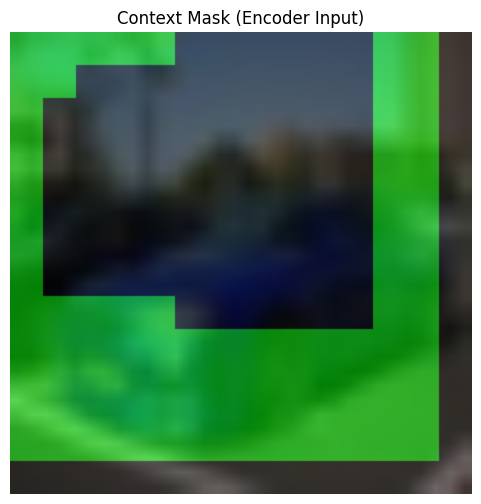

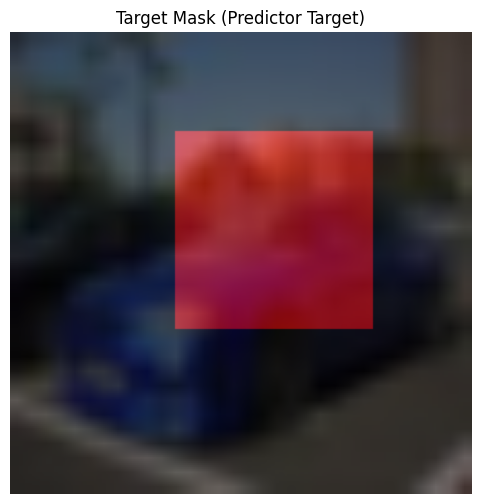

In [11]:
import torch
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
import yaml
import os
from pathlib import Path
from PIL import Image
import logging # Added import for logging

# Ensure the repo directory is in sys.path for importing custom modules
if 'REPO_DIR' in locals() and REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# Helper function to load configs
def load_config(config_path):
    with open(config_path) as f:
        return yaml.safe_load(f)

# Load config
cfg = load_config(CONFIG_PATH)
p_cfg, d_cfg, m_cfg = cfg['pretrain'], cfg['data'], cfg['mask']
IMG_SIZE, PATCH_SIZE = p_cfg['image_size'][0], p_cfg['patch_size'] # Set IMG_SIZE back to the default from config

# Import MaskCollator from the cloned repository
from src.masks.multiblock import MaskCollator

mask_collator = MaskCollator(
    input_size=(IMG_SIZE, IMG_SIZE), patch_size=PATCH_SIZE,
    enc_mask_scale=m_cfg['enc_mask_scale'], pred_mask_scale=m_cfg['pred_mask_scale'],
    aspect_ratio=m_cfg['aspect_ratio'], nenc=m_cfg['nenc'], npred=m_cfg['npred'],
    allow_overlap=m_cfg['allow_overlap'], min_keep=m_cfg['min_keep'])

# Load a sample image from the dataset path
sample_image_path = next(Path(DATASET_PATH).rglob('*.png'), None) or \
                    next(Path(DATASET_PATH).rglob('*.jpg'), None)

if sample_image_path is None:
    print("No sample image found in DATASET_PATH. Cannot visualize masks.")
else:
    original_pil_img = Image.open(sample_image_path).convert('RGB')

    # Define the data transformation pipeline for generating masks, matching the training script
    data_transform = T.Compose([
        T.Resize(int(IMG_SIZE * 1.15)),
        T.RandomCrop(IMG_SIZE),
        T.RandomHorizontalFlip() if d_cfg.get('use_horizontal_flip', True) else T.Lambda(lambda x: x),
        T.ColorJitter(0.8*d_cfg['color_jitter_strength'], 0.8*d_cfg['color_jitter_strength'], 0.8*d_cfg['color_jitter_strength'], 0.2*d_cfg['color_jitter_strength']) if d_cfg.get('color_jitter_strength', 0.0) > 0 else T.Lambda(lambda x: x),
        T.ToTensor(),
        T.Normalize(mean=d_cfg['normalization']['mean'], std=d_cfg['normalization']['std'])
    ])

    # Transform the image and add a batch dimension for the mask_collator
    img_tensor_for_masking = data_transform(original_pil_img).unsqueeze(0)

    # Temporarily suppress warnings from the mask generator
    original_logging_level = logging.getLogger().level
    logging.getLogger().setLevel(logging.ERROR) # Set to ERROR or CRITICAL to suppress warnings

    # Generate masks using the mask_collator.
    # Based on kernel state, mask_collator is returning a 3-element tuple:
    # (input_batch_info, encoder_masks_list, predictor_masks_list_outer).
    # We unpack it accordingly.
    # Fix: Replace None with a dummy tensor for the label to avoid TypeError in default_collate
    _input_batch_info, enc_masks_list, pred_masks_list_outer = mask_collator([(img_tensor_for_masking[0], torch.tensor(0))])

    # Reset logging level to its original state
    logging.getLogger().setLevel(original_logging_level)

    # Extract the first mask from the encoder list
    enc_mask_patches = enc_masks_list[0].cpu().numpy() if enc_masks_list else None

    # Extract the first predictor mask from the list of predictor masks.
    # pred_masks_list_outer is a list of tensors. We want the first tensor in this list.
    pred_mask_patches = pred_masks_list_outer[0].cpu().numpy() if pred_masks_list_outer else None

    # Prepare a version of the image for display (without normalization for visual clarity)
    display_transform_no_norm = T.Compose([
        T.Resize(IMG_SIZE),
        T.CenterCrop(IMG_SIZE),
        T.ToTensor()
    ])
    img_display_np = display_transform_no_norm(original_pil_img).permute(1, 2, 0).numpy()
    img_display_np = np.clip(img_display_np, 0, 1) # Ensure values are in [0, 1] for imshow

    # Visualization function to overlay patch masks on an image
    def plot_mask_overlay(image_np, patch_mask_array, title, color=[1, 0, 0], alpha=0.5):
        if patch_mask_array is None:
            print(f"No mask data for: {title}")
            return

        fig, ax = plt.subplots(1, 1, figsize=(6, 6))
        ax.imshow(image_np)
        ax.set_title(title)
        ax.axis('off')

        num_patches_h = image_np.shape[0] // PATCH_SIZE
        num_patches_w = image_np.shape[1] // PATCH_SIZE
        total_patches = num_patches_h * num_patches_w

        # patch_mask_array contains indices of the selected patches.
        # It needs to be flattened if it's a 2D array like [[idx1, idx2, ...]].
        flat_patch_indices = patch_mask_array.flatten() if patch_mask_array.ndim > 1 else patch_mask_array

        if not flat_patch_indices.size > 0:
            print(f"No patches selected for: {title}")
            return

        # Create a boolean mask grid of the correct total_patches size
        mask_grid_flat = np.zeros(total_patches, dtype=bool)
        # Set True for the patches indicated by flat_patch_indices
        mask_grid_flat[flat_patch_indices] = True

        # Reshape the flattened boolean mask to a 2D grid
        mask_grid = mask_grid_flat.reshape(num_patches_h, num_patches_w)

        # Create an overlay for the masked regions
        overlay = np.zeros_like(image_np)
        overlay_mask = np.zeros(image_np.shape[:2], dtype=bool)

        for r in range(num_patches_h):
            for c in range(num_patches_w):
                if mask_grid[r, c]:
                    # Mark the patch region as masked
                    overlay_mask[r*PATCH_SIZE:(r+1)*PATCH_SIZE, c*PATCH_SIZE:(c+1)*PATCH_SIZE] = True

        # Apply the specified color to the masked regions
        overlay[overlay_mask] = color
        ax.imshow(overlay, alpha=alpha)
        plt.show()

    # Visualize the masks
    if enc_mask_patches is not None:
        plot_mask_overlay(img_display_np, enc_mask_patches, 'Context Mask (Encoder Input)', color=[0, 1, 0]) # Green
    if pred_mask_patches is not None:
        plot_mask_overlay(img_display_np, pred_mask_patches, 'Target Mask (Predictor Target)', color=[1, 0, 0]) # Red

---
## 9 · Next Steps

```python
import torch
ckpt = torch.load('ijepa-ep010.pth', map_location='cpu')
print(ckpt.keys())  # 'epoch', 'encoder', 'predictor', 'loss_log'
```

| What | How |
|------|-----|
| Bigger model | Change `model_name` to `vit_base` / `vit_large` / `vit_huge` in cell 4 |
| More epochs | Increase `num_epochs` in cell 4 |
| ImageNet | Set `USE_CIFAR = False` and point `DATA_ROOT` at your ImageNet root |
| Resume | Set `load_checkpoint: True` + `read_checkpoint: 'ijepa-epXXX.pth'` |
| W&B | Add `WANDB_API_KEY` to secrets — auto-detected in cell 1 |

Tensor equation for I-JEPA (Mean Squared Error):
$$\mathcal{L} = \|g_\phi(f_\theta(x \odot m_c), m_t) - f_\xi(x \odot m_t)\|^2$$
where:

* $f_\theta$ = context encoder
* $f_\xi$ = target encoder (often EMA teacher)
* $m_c$ = context mask
* $m_t$ = target block mask

With constraints like $m_c \cap m_t = \varnothing$, but not $m_c \cup m_t = 1$.


------------------------------
The symbol
$$\odot$$
means elementwise multiplication (also called the Hadamard product).
In the I-JEPA equations:
$$x_c = x \odot m_c$$
it means:

apply the mask $m_c$ to the image tensor $x$.

If:

* $x$ is the image tensor
* $m_c$ is a binary mask tensor

then:
$$m_c(i, j) = \begin{cases} 1 & \text{keep this patch/pixel} \\ 0 & \text{hide this patch/pixel} \end{cases}$$
and:
$$(x \odot m_c)(i, j) = x(i, j) \, m_c(i, j)$$
So:

* multiplying by $1$ keeps the value
* multiplying by $0$ removes it.

Example:
$$x = \begin{bmatrix} 4 & 7 \\ 2 & 9 \end{bmatrix}$$
$$m = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$$
then:
$$x \odot m = \begin{bmatrix} 4 & 0 \\ 0 & 9 \end{bmatrix}$$